In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [215]:
df=pd.read_csv('/Users/zoetankersley/sunrise_social_club/data/processed/sales_merged.csv')

In [216]:
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-07-14,12:52:38,Matcha Latte,Matcha Latte,Oat Milk,False,1.0,9.0,16oz,True,Peach,79.0,Sunny,Market,Kill Devil Hills
1,2026-07-14,12:29:14,Lemonade,Lemonade,Lemonade,False,1.0,3.0,12oz,False,NaN,79.0,Sunny,Market,Kill Devil Hills
2,2026-07-14,12:29:14,Cold Brew,Cold Brew,Oat Milk,False,1.0,6.0,12oz,False,Coconut,79.0,Sunny,Market,Kill Devil Hills
3,2026-07-14,12:25:56,Lemonade,Lemonade,Lemonade,False,1.0,4.0,12oz,False,Peach,79.0,Sunny,Market,Kill Devil Hills
4,2026-07-14,12:25:56,Matcha Latte,Matcha Latte,Whole Milk,False,1.0,8.0,16oz,False,Vanilla,79.0,Sunny,Market,Kill Devil Hills


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2541 entries, 0 to 2540
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               2541 non-null   object 
 1   Time               2541 non-null   object 
 2   Original_Item      2541 non-null   object 
 3   Item               2541 non-null   object 
 4   Base               2068 non-null   object 
 5   Signature_Drink    2541 non-null   bool   
 6   Qty                2541 non-null   float64
 7   Net_Sales          2541 non-null   float64
 8   Size               2200 non-null   object 
 9   Cold_Foam          2541 non-null   bool   
 10  Flavor             2075 non-null   object 
 11  Avg_Temp           2541 non-null   float64
 12  Weather_Condition  2541 non-null   object 
 13  Event_Type         2541 non-null   object 
 14  Location           2541 non-null   object 
dtypes: bool(2), float64(3), object(10)
memory usage: 263.2+ KB


In [218]:
df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte    9436.42
Cold Brew       6768.00
Lemonade        2447.00
Sticker          370.00
Mug              150.00
Name: Net_Sales, dtype: float64

In [219]:
df.groupby("Flavor")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Flavor
Strawberry               5528.58
Salted Maple             2599.66
Blueberry                2522.00
Vanilla                  1564.00
Banana                   1300.00
Coconut                  1111.00
Cinn Roll                 868.00
Strawberry, Blueberry     441.00
Horchata                  339.00
Cake Batter               224.00
Name: Net_Sales, dtype: float64

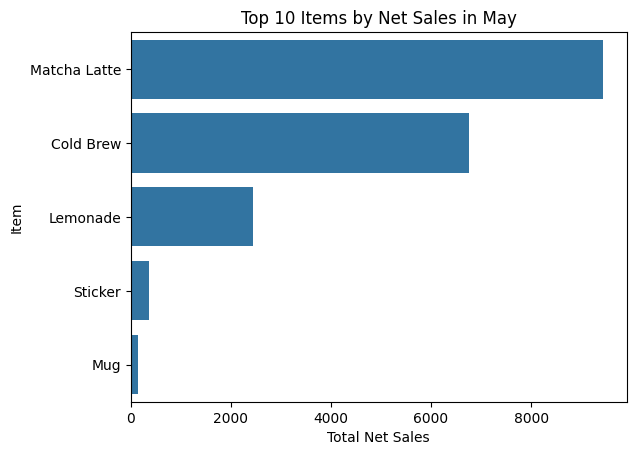

In [220]:
sns.barplot(x=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).values, y=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).index)
plt.xlabel("Total Net Sales")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Sales in May")
plt.show()

In [221]:
df.groupby("Item")["Qty"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte    1146.0
Cold Brew        930.0
Lemonade         568.0
Sticker          186.0
Mug                2.0
Name: Qty, dtype: float64

In [222]:
df.groupby("Event_Type")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Event_Type
Market    17800.42
Popup      1371.00
Name: Net_Sales, dtype: float64

In [223]:
df["Cold_Foam"].value_counts()

Cold_Foam
True     1332
False    1209
Name: count, dtype: int64

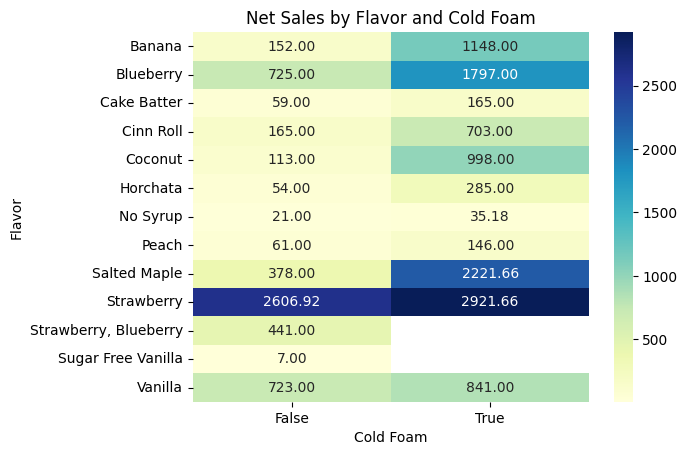

In [224]:
pivot = df.pivot_table(
    index="Flavor",
    columns="Cold_Foam",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Cold Foam")
plt.xlabel("Cold Foam")
plt.ylabel("Flavor")
plt.show()

In [225]:
df["Flavor"].value_counts()

Flavor
Strawberry               691
Salted Maple             314
Blueberry                313
Vanilla                  189
Banana                   151
Coconut                  129
Cinn Roll                104
Strawberry, Blueberry     88
Horchata                  39
Peach                     25
Cake Batter               23
No Syrup                   8
Sugar Free Vanilla         1
Name: count, dtype: int64

In [226]:
df.groupby("Item")["Net_Sales"].sum() / df.groupby("Item")["Qty"].sum()

Item
Cold Brew        7.277419
Lemonade         4.308099
Matcha Latte     8.234223
Mug             75.000000
Sticker          1.989247
dtype: float64

In [227]:
pd.crosstab(df["Flavor"], df["Cold_Foam"])

Cold_Foam,False,True
Flavor,,
Banana,21,130
Blueberry,109,204
Cake Batter,5,18
Cinn Roll,23,81
Coconut,15,114
Horchata,7,32
No Syrup,3,5
Peach,10,15
Salted Maple,50,264


In [228]:
df["Base"].value_counts()

Base
Whole Milk    855
Oat Milk      593
Lemonade      583
No Milk        37
Name: count, dtype: int64

In [229]:
df.groupby("Base")["Net_Sales"].sum()

Base
Lemonade      3252.18
No Milk        274.00
Oat Milk      5009.00
Whole Milk    7462.58
Name: Net_Sales, dtype: float64

In [230]:
pd.crosstab(df["Item"], df["Base"])

Base,Lemonade,No Milk,Oat Milk,Whole Milk
Item,,,,
Cold Brew,0,36,229,434
Lemonade,481,0,0,0
Matcha Latte,102,1,364,421


In [231]:
df.groupby("Item")["Avg_Temp"].mean()

Item
Cold Brew       81.233021
Lemonade        81.559252
Matcha Latte    80.992417
Mug             75.000000
Sticker         80.510067
Name: Avg_Temp, dtype: float64

In [232]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/var/folders/w2/4nk24xz14yg09dbpyrxdn4c80000gn/T/ipykernel_73945/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


In [233]:
df.groupby("Hour")["Net_Sales"].sum()

Hour
6      202.00
7       95.00
8      236.00
9     5966.00
10    5265.00
11    4577.42
12    2500.00
13     257.00
14      73.00
Name: Net_Sales, dtype: float64

In [234]:
pd.crosstab(df["Hour"], df["Item"])

Item,Cold Brew,Lemonade,Matcha Latte,Mug,Sticker
Hour,,,,,
6,12,2,13,0,2
7,5,1,7,0,0
8,9,2,16,0,0
9,314,92,311,0,51
10,268,148,254,0,36
11,173,143,259,1,39
12,71,81,168,1,18
13,2,10,20,0,3
14,0,2,7,0,0


In [235]:
df.groupby(
    ["Item","Base","Flavor","Cold_Foam"]
)["Net_Sales"].sum().sort_values(ascending=False)

Item          Base        Flavor        Cold_Foam
Matcha Latte  Whole Milk  Strawberry    True         1479.66
Cold Brew     Whole Milk  Salted Maple  True         1094.00
Lemonade      Lemonade    Strawberry    False        1055.00
Matcha Latte  Oat Milk    Strawberry    True          941.00
              Lemonade    Strawberry    False         777.00
                                                      ...   
Cold Brew     No Milk     Salted Maple  False           7.00
                          Cinn Roll     True            7.00
Lemonade      Lemonade    Blueberry     True            6.00
Cold Brew     No Milk     Vanilla       False           6.00
Lemonade      Lemonade    Coconut       True            6.00
Name: Net_Sales, Length: 93, dtype: float64

In [236]:
df.groupby(
    ["Item","Base","Flavor","Cold_Foam"]
)["Qty"].sum().sort_values(ascending=False).head(20)

Item          Base        Flavor                 Cold_Foam
Lemonade      Lemonade    Strawberry             False        228.0
Matcha Latte  Whole Milk  Strawberry             True         171.0
Cold Brew     Whole Milk  Salted Maple           True         141.0
Matcha Latte  Oat Milk    Strawberry             True         109.0
              Lemonade    Strawberry             False        102.0
Lemonade      Lemonade    Strawberry, Blueberry  False         96.0
Cold Brew     Whole Milk  Banana                 True          68.0
              Oat Milk    Salted Maple           True          60.0
Matcha Latte  Whole Milk  Blueberry              True          59.0
Lemonade      Lemonade    Blueberry              False         56.0
Cold Brew     Whole Milk  Blueberry              True          55.0
Matcha Latte  Oat Milk    Blueberry              True          45.0
                          Strawberry             False         41.0
Cold Brew     Whole Milk  Vanilla                True    

In [237]:
pd.crosstab(
    [df["Item"], df["Base"], df["Flavor"], df["Cold_Foam"]],
    df["Event_Type"],
    values=df["Net_Sales"],
    aggfunc="sum"
)

Event_Type                                       Market  Popup
Item         Base       Flavor       Cold_Foam                
Cold Brew    No Milk    Banana       True          8.00    NaN
                        Blueberry    True         63.00    NaN
                        Cinn Roll    True          7.00    NaN
                        Salted Maple False         7.00    NaN
                                     True         30.00    NaN
...                                                 ...    ...
Matcha Latte Whole Milk Salted Maple True        206.00    9.0
                        Strawberry   False       147.92   92.0
                                     True       1386.66   93.0
                        Vanilla      False       149.00    7.0
                                     True        168.00    9.0

[93 rows x 2 columns]

In [238]:
df.isna().sum()

Date                   0
Time                   0
Original_Item          0
Item                   0
Base                 473
Signature_Drink        0
Qty                    0
Net_Sales              0
Size                 341
Cold_Foam              0
Flavor               466
Avg_Temp               0
Weather_Condition      0
Event_Type             0
Location               0
Hour                   0
dtype: int64

In [239]:
df[df['Base'].isna()]['Item'].value_counts()

Item
Matcha Latte    167
Cold Brew       155
Sticker         149
Mug               2
Name: count, dtype: int64

In [240]:
df[(df['Base'].isna()) & (df['Item'] == 'Matcha Latte')]

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location,Hour
173,2026-07-11,12:24:59,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,12oz,False,Strawberry,85.0,Rainy,Market,Manteo,12
608,2026-07-07,09:53:22,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,16oz,False,NaN,88.0,Partly Cloudy,Market,Kill Devil Hills,9
886,2026-06-30,11:19:09,Matcha Latte,Matcha Latte,NaN,False,1.0,8.0,16oz,False,Blueberry,77.0,Sunny,Market,Kill Devil Hills,11
922,2026-06-30,10:32:37,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,16oz,False,NaN,77.0,Sunny,Market,Kill Devil Hills,10
930,2026-06-30,10:23:08,Matcha Latte,Matcha Latte,NaN,False,1.0,9.0,16oz,True,Strawberry,77.0,Sunny,Market,Kill Devil Hills,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511,2026-05-23,09:40:00,Matcha Latte,Matcha Latte,NaN,False,2.0,16.0,12oz,True,NaN,77.0,Partly Cloudy,Popup,Kill Devil Hills,9
2512,2026-05-23,09:38:39,Matcha Latte,Matcha Latte,NaN,False,1.0,9.0,16oz,True,Strawberry,77.0,Partly Cloudy,Popup,Kill Devil Hills,9
2517,2026-05-23,09:35:07,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,NaN,77.0,Partly Cloudy,Popup,Kill Devil Hills,9
2524,2026-05-23,09:28:24,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,NaN,77.0,Partly Cloudy,Popup,Kill Devil Hills,9


In [241]:
order_level = df.groupby(["Date", "Time"])["Net_Sales"].sum()
order_level.describe()

count    1665.000000
mean       11.514366
std         6.531611
min         2.000000
25%         8.000000
50%         9.000000
75%        15.000000
max        93.000000
Name: Net_Sales, dtype: float64

In [242]:
recent=df[df["Date"]>="2026-06-20"]

In [243]:
recent.groupby('Item')['Qty'].sum()

Item
Cold Brew       665.0
Lemonade        356.0
Matcha Latte    653.0
Sticker         109.0
Name: Qty, dtype: float64